In [1]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.decomposition import PCA

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = tf.image.resize(x_train[..., None].astype("float32"), (32, 32)).numpy() / 255.0
x_test = tf.image.resize(x_test[..., None].astype("float32"), (32, 32)).numpy() / 255.0
print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 32, 32, 1) (10000, 32, 32, 1)


In [3]:
latent_dim = 16

class Encoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')
        self.conv3 = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')
        self.flatten = layers.Flatten()
        self.z_mean = layers.Dense(latent_dim)
        self.z_log_var = layers.Dense(latent_dim)

    def call(self, x):
        h = self.conv1(x)
        h = self.conv2(h)
        h = self.conv3(h)
        h = self.flatten(h)
        mu = self.z_mean(h)
        lv = self.z_log_var(h)
        eps = tf.random.normal(tf.shape(mu))
        z = mu + tf.exp(0.5 * lv) * eps
        return z, mu, lv

In [4]:
class Decoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.dense = layers.Dense(4 * 4 * 128, activation='relu')
        self.reshape = layers.Reshape((4, 4, 128))
        self.deconv1 = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')
        self.deconv2 = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')
        self.deconv3 = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')
        self.out = layers.Conv2DTranspose(1, 3, strides=1, padding='same', activation='sigmoid')

    def call(self, z):
        h = self.dense(z)
        h = self.reshape(h)
        h = self.deconv1(h)
        h = self.deconv2(h)
        h = self.deconv3(h)
        return self.out(h)

In [5]:
class CVAE(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.rt = tf.keras.metrics.Mean()
        self.kt = tf.keras.metrics.Mean()
        self.et = tf.keras.metrics.Mean()

    @property
    def metrics(self): return [self.rt, self.kt, self.et]

    def train_step(self, x):
        with tf.GradientTape() as tape:
            z, mu, lv = self.encoder(x)
            xr = self.decoder(z)
            rec = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, xr), axis=(1, 2)))
            kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + lv - tf.square(mu) - tf.exp(lv), axis=1))
            loss = rec + kl
        g = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(g, self.trainable_weights))
        self.rt.update_state(rec); self.kt.update_state(kl); self.et.update_state(loss)
        return {"reconstruction": self.rt.result(), "kl": self.kt.result(), "elbo": self.et.result()}

In [6]:
cvae = CVAE(latent_dim)
cvae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
history = cvae.fit(x_train, epochs=15, batch_size=128, verbose=1)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - elbo: 224.3136 - kl: 14.2773 - reconstruction: 210.0364
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - elbo: 155.3670 - kl: 23.0521 - reconstruction: 132.3149
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - elbo: 150.9715 - kl: 23.4346 - reconstruction: 127.5369
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - elbo: 148.9471 - kl: 23.5306 - reconstruction: 125.4165
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - elbo: 147.6382 - kl: 23.5536 - reconstruction: 124.0845
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - elbo: 146.5970 - kl: 23.4598 - reconstruction: 123.1372
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - elbo: 145.8487 - kl: 23.4264 - reconstruction: 122.4223
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - elbo: 145.1931 - kl: 23.3993 - reconstruction: 121.7937
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - elbo: 144.7030 - kl: 23.3547 - reconstruction: 1

In [7]:
enc_params = cvae.encoder.count_params()
dec_params = cvae.decoder.count_params()
total_params = enc_params + dec_params
compression = (32 * 32) / latent_dim
print("Encoder parameters:", enc_params)
print("Decoder parameters:", dec_params)
print("Total VAE parameters:", total_params)
print("Compression ratio:", compression)

Encoder parameters: 158240
Decoder parameters: 274945
Total VAE parameters: 433185
Compression ratio: 64.0


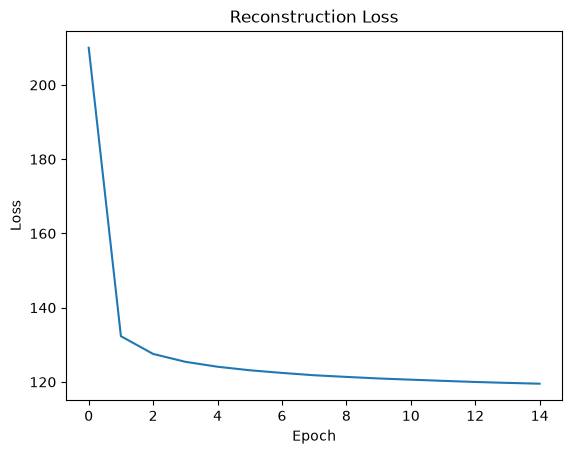

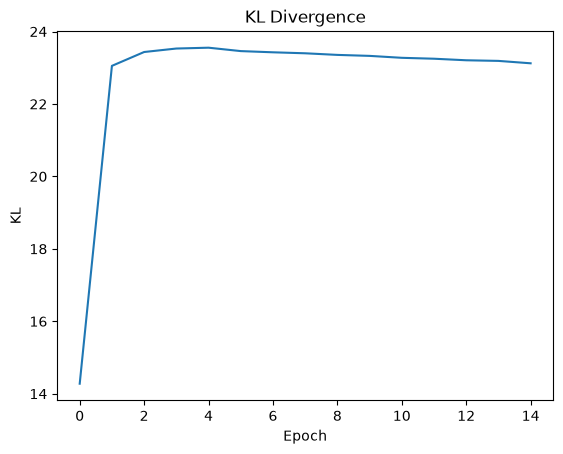

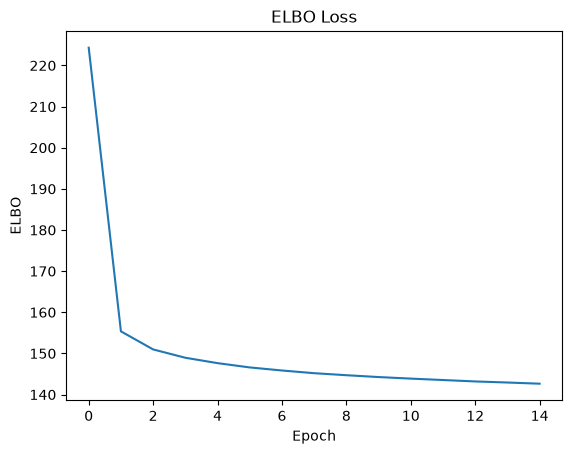

In [8]:
plt.figure(); plt.plot(history.history['reconstruction']); plt.title("Reconstruction Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()

plt.figure(); plt.plot(history.history['kl']); plt.title("KL Divergence")
plt.xlabel("Epoch"); plt.ylabel("KL"); plt.show()

plt.figure(); plt.plot(history.history['elbo']); plt.title("ELBO Loss")
plt.xlabel("Epoch"); plt.ylabel("ELBO"); plt.show()

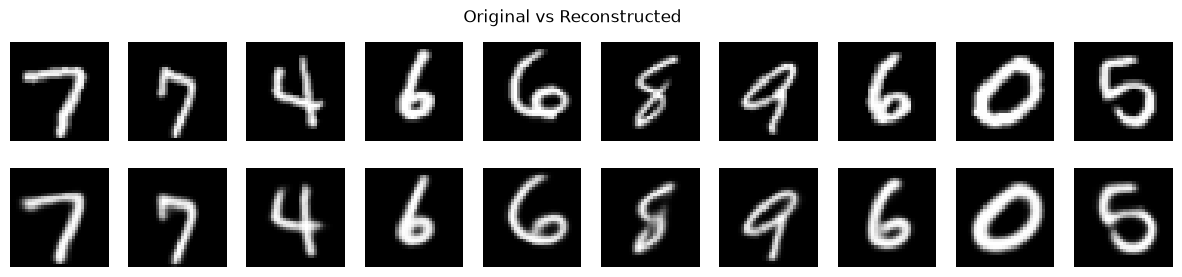

In [9]:
sel = np.random.choice(len(x_test), 10, replace=False)
z, mu, lv = cvae.encoder.predict(x_test[sel], verbose=0)
recon = cvae.decoder.predict(z, verbose=0)

fig, ax = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle("Original vs Reconstructed")
for i in range(10):
    ax[0, i].imshow(x_test[sel[i]].squeeze(), cmap='gray'); ax[0, i].axis('off')
    ax[1, i].imshow(recon[i].squeeze(), cmap='gray'); ax[1, i].axis('off')
plt.show()

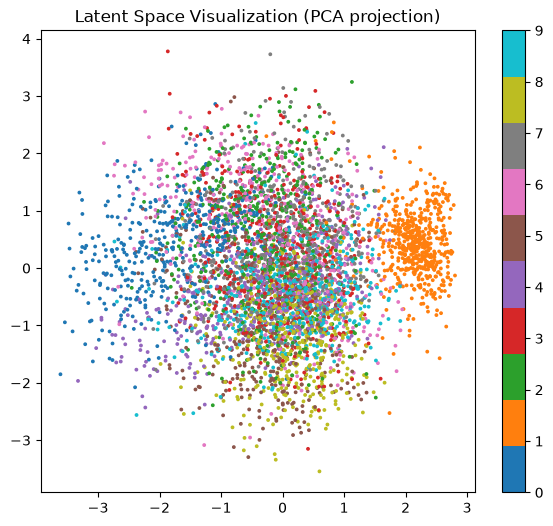

In [10]:
z_all, mu_all, lv_all = cvae.encoder.predict(x_test[:5000], verbose=0)
z2d = PCA(n_components=2).fit_transform(mu_all)

plt.figure(figsize=(7, 6))
plt.scatter(z2d[:, 0], z2d[:, 1], c=y_test[:5000], s=3, cmap='tab10')
plt.colorbar()
plt.title("Latent Space Visualization (PCA projection)")
plt.show()

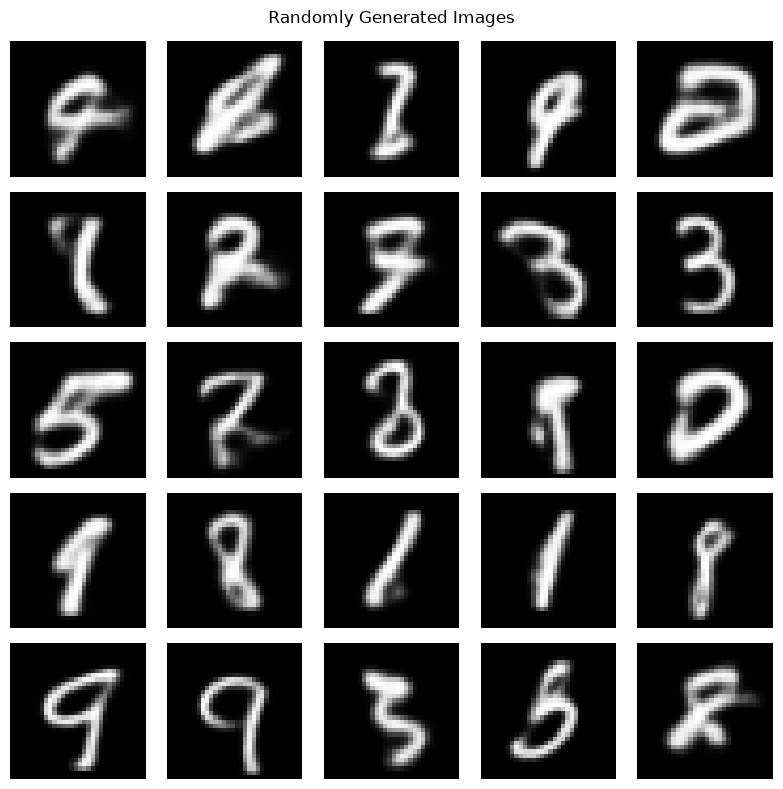

In [11]:
z_random = np.random.normal(size=(25, latent_dim)).astype("float32")
gen_imgs = cvae.decoder.predict(z_random, verbose=0)

plt.figure(figsize=(8, 8))
plt.suptitle("Randomly Generated Images")
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
print("Final reconstruction loss:", history.history['reconstruction'][-1])
print("Final KL divergence:", history.history['kl'][-1])
print("Final ELBO:", history.history['elbo'][-1])
print("Compression ratio (32x32 image -> latent dim {}): {}".format(latent_dim, compression))

Final reconstruction loss: 119.5178451538086
Final KL divergence: 23.122905731201172
Final ELBO: 142.64073181152344
Compression ratio (32x32 image -> latent dim 16): 64.0
